### Preprocessing

In [1]:
import librosa
import numpy as np

SAMPLE_RATE = 22050
DURATION = 5
SAMPLES = SAMPLE_RATE * DURATION
N_MELS = 128

def preprocess_audio(file_path, augment=False):

    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # Fix length
    if len(signal) > SAMPLES:
        signal = signal[:SAMPLES]
    else:
        signal = np.pad(signal, (0, SAMPLES - len(signal)))

    # ✅ AUDIO AUGMENTATION
    if augment:
        # Random noise
        noise = np.random.randn(len(signal))
        signal = signal + 0.005 * noise

        # Time shift
        shift = np.random.randint(SAMPLE_RATE)
        signal = np.roll(signal, shift)

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        fmax=8000
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ✅ Add delta features (VERY IMPORTANT)
    delta = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    # Stack → (128, time, 3)
    feature = np.stack([mel_db, delta, delta2], axis=-1)

    # Normalize
    feature = (feature - np.mean(feature)) / (np.std(feature) + 1e-6)

    return feature

### Load Dataset

In [2]:
import os

CLASS_NAMES = ["asthma", "copd", "Bronchial", "pneumonia", "healthy"]

def load_dataset(path):

    X, y = [], []

    for label, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(path, cls)

        for file in os.listdir(folder):
            if file.endswith(".wav"):
                file_path = os.path.join(folder, file)

                try:
                    # Original
                    X.append(preprocess_audio(file_path, augment=False))
                    y.append(label)

                    # Augmented copy
                    X.append(preprocess_audio(file_path, augment=True))
                    y.append(label)

                except:
                    print("Error loading:", file)

    return np.array(X), np.array(y)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir("."))

Current working directory: /content
Files in current directory: ['.config', 'drive', 'sample_data']


In [17]:

DATASET_PATH = "/content/drive/MyDrive/datasets/Audio_Detection_Dataset/"
X, y = load_dataset(DATASET_PATH)

X = X[..., np.newaxis]  # add channel




### Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


y_train = to_categorical(y_train, num_classes=5)
y_val = to_categorical(y_val, num_classes=5)

### Handle Class Imbalance

### Model Code

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model():

    inputs = layers.Input(shape=(128, 216, 3))

    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)

    # ✅ Global pooling (reduces overfitting)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(5, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model
model=build_model()

In [21]:


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 216, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 216, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 13, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        patience=15,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

In [23]:
print(y_train.shape)
print(y_val.shape)

(1937, 5)
(485, 5)


In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.4269 - loss: 1.4381 - val_accuracy: 0.2351 - val_loss: 1.7447 - learning_rate: 1.0000e-04
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5700 - loss: 1.2373 - val_accuracy: 0.3237 - val_loss: 1.7465 - learning_rate: 1.0000e-04
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6273 - loss: 1.1245 - val_accuracy: 0.5443 - val_loss: 1.3992 - learning_rate: 1.0000e-04
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6603 - loss: 1.0621 - val_accuracy: 0.6227 - val_loss: 1.1659 - learning_rate: 1.0000e-04
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6995 - loss: 1.0106 - val_accuracy: 0.6660 - val_loss: 1.0379 - learning_rate: 1.0000e-04
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7212 - loss: 0.9659 - val_accuracy: 0.5546 - val_loss: 1.1891 - learning_rate: 1.0000e-04
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - ac

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred = np.argmax(model.predict(X_val), axis=1)

# Convert one-hot → labels
y_true = np.argmax(y_val, axis=1)

# Confusion Matrix
print(confusion_matrix(y_true, y_pred))

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[101   5   0   1   8]
 [  4 152   1   2   2]
 [  7   1  33   0   1]
 [  8   2   0  98   6]
 [  0   1   0   6  46]]
              precision    recall  f1-score   support

      asthma       0.84      0.88      0.86       115
        copd       0.94      0.94      0.94       161
   Bronchial       0.97      0.79      0.87        42
   pneumonia       0.92      0.86      0.89       114
     healthy       0.73      0.87      0.79        53

    accuracy                           0.89       485
   macro avg       0.88      0.87      0.87       485
weighted avg       0.89      0.89      0.89       485



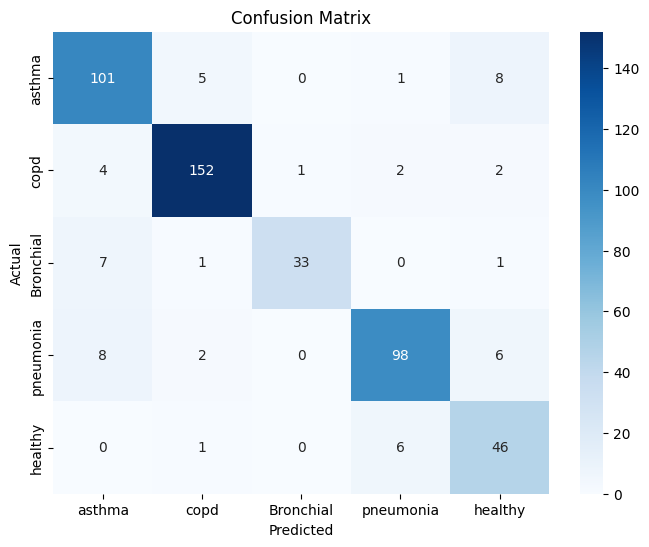

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()